# Random Forest Classifier

🎯 You are a Data Scientist for a bank. You are asked to develop a model that is able to detect at least 90% of fraudulent transactions. Go!

In [1]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data_init = pd.read_csv("../raw_data/fraudTrain.csv")
data_init.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Preprocessing

👇 Check class balance.

In [2]:
data=data_init.sample(frac=0.1)
#data=data_init

In [3]:
data.is_fraud.value_counts()

is_fraud
0    128912
1       756
Name: count, dtype: int64

In [4]:
# DEFINING THE TARGET
y = data['is_fraud'] # the price here is either expensive or cheap

# DEFINING THE FEATURES
X = data.drop(columns=['is_fraud'])

In [5]:
#Drop columns which have little impact on results
X.drop(columns=['Unnamed: 0','unix_time','cc_num','first', 'last', 'street', 'city', 'state', 'zip', 'city_pop', 'trans_num'],inplace=True)
X.head()

,trans_date_trans_time,merchant,category,amt,gender,lat,long,job,dob,merch_lat,merch_long
22572,2019-01-14 11:09:15,fraud_Goodwin-Nitzsche,grocery_pos,191.10,F,46.1966,-118.9017,Musician,1981-11-29,45.790265,-119.772668
566121,2019-08-29 04:26:13,fraud_Kerluke-Abshire,shopping_net,100.46,M,39.3900,-88.9597,Radio broadcast assistant,1980-01-09,39.597102,-88.806151
360408,2019-06-16 22:05:44,fraud_Bins-Tillman,entertainment,31.22,M,35.8896,-96.0887,Fitness centre manager,1982-02-05,35.976805,-95.368213
403779,2019-07-01 23:57:11,"fraud_Kling, Howe and Schneider",home,216.49,M,32.9396,-105.8189,Naval architect,1967-08-30,32.959811,-104.944996
961421,2020-01-22 10:31:15,fraud_Kiehn Inc,grocery_pos,148.52,F,44.8816,-73.6408,"Surveyor, land/geomatics",1953-05-23,45.473947,-73.279278


In [6]:
#Transform date/time into a good format
import datetime
X['dob'] = pd.to_datetime(X['dob'])
X['trans_date_trans_time'] = pd.to_datetime(X['trans_date_trans_time'])
X.dtypes

trans_date_trans_time    datetime64[ns]
merchant                         object
category                         object
amt                             float64
gender                           object
lat                             float64
long                            float64
job                              object
dob                      datetime64[ns]
merch_lat                       float64
merch_long                      float64
dtype: object

In [7]:
#Drop job and merchant because to many classes. But it is possible to keep them
X.drop(columns=['job','merchant'],inplace=True)
X.head()

,trans_date_trans_time,category,amt,gender,lat,long,dob,merch_lat,merch_long
22572,2019-01-14 11:09:15,grocery_pos,191.10,F,46.1966,-118.9017,1981-11-29,45.790265,-119.772668
566121,2019-08-29 04:26:13,shopping_net,100.46,M,39.3900,-88.9597,1980-01-09,39.597102,-88.806151
360408,2019-06-16 22:05:44,entertainment,31.22,M,35.8896,-96.0887,1982-02-05,35.976805,-95.368213
403779,2019-07-01 23:57:11,home,216.49,M,32.9396,-105.8189,1967-08-30,32.959811,-104.944996
961421,2020-01-22 10:31:15,grocery_pos,148.52,F,44.8816,-73.6408,1953-05-23,45.473947,-73.279278


In [8]:
X['age'] = (X['trans_date_trans_time'] - X['dob']).dt.days / 365.25
X['trans_month']=pd.to_datetime(X['trans_date_trans_time']).dt.month
X['trans_day']=pd.to_datetime(X['trans_date_trans_time']).dt.day
X['trans_hour']=pd.to_datetime(X['trans_date_trans_time']).dt.hour
X.tail(5)

,trans_date_trans_time,category,amt,gender,lat,long,dob,merch_lat,merch_long,age,trans_month,trans_day,trans_hour
857431,2019-12-16 17:38:40,travel,36.41,F,40.4542,-98.6538,1950-08-19,40.879056,-97.822584,69.325120,12,16,17
514445,2019-08-10 23:52:13,health_fitness,8.80,M,27.9611,-81.9398,1961-09-28,28.813461,-81.447350,57.864476,8,10,23
923818,2019-12-31 17:03:08,food_dining,23.01,M,41.2064,-95.9953,1995-10-10,40.926335,-95.477874,24.224504,12,31,17
404612,2019-07-02 12:59:38,home,32.19,F,42.9147,-83.4845,1985-06-18,43.536560,-83.535610,34.036961,7,2,12
1233751,2020-05-30 05:58:02,gas_transport,57.24,M,38.8564,-80.1580,1967-09-16,39.216877,-79.890110,52.703628,5,30,5


In [9]:
X.drop(columns=['trans_date_trans_time','dob'],inplace=True)
X.head()

,category,amt,gender,lat,long,merch_lat,merch_long,age,trans_month,trans_day,trans_hour
22572,grocery_pos,191.10,F,46.1966,-118.9017,45.790265,-119.772668,37.125257,1,14,11
566121,shopping_net,100.46,M,39.3900,-88.9597,39.597102,-88.806151,39.635866,8,29,4
360408,entertainment,31.22,M,35.8896,-96.0887,35.976805,-95.368213,37.357974,6,16,22
403779,home,216.49,M,32.9396,-105.8189,32.959811,-104.944996,51.835729,7,1,23
961421,grocery_pos,148.52,F,44.8816,-73.6408,45.473947,-73.279278,66.666667,1,22,10


In [10]:
#Use cyclic (sin/cos) encoding for month, day, weekday
X["trans_month_sin"] = np.sin(2 * np.pi * X["trans_month"] / 12)
X["trans_month_cos"] = np.cos(2 * np.pi * X["trans_month"] / 12)

X["trans_day_sin"] = np.sin(2 * np.pi * X["trans_day"] / 31)
X["trans_day_cos"] = np.cos(2 * np.pi * X["trans_day"] / 31)

X["trans_hour_sin"] = np.sin(2 * np.pi * X["trans_hour"] / 24)
X["trans_hour_cos"] = np.cos(2 * np.pi * X["trans_hour"] / 24)

In [11]:
#Drop'trans_month','trans_day','trans_hour'
X.drop(columns=['trans_month','trans_day','trans_hour'],inplace=True)

In [12]:
X.head()

,category,amt,gender,lat,long,merch_lat,merch_long,age,trans_month_sin,trans_month_cos,trans_day_sin,trans_day_cos,trans_hour_sin,trans_hour_cos
22572,grocery_pos,191.10,F,46.1966,-118.9017,45.790265,-119.772668,37.125257,5.000000e-01,0.866025,0.299363,-0.954139,0.258819,-0.965926
566121,shopping_net,100.46,M,39.3900,-88.9597,39.597102,-88.806151,39.635866,-8.660254e-01,-0.500000,-0.394356,0.918958,0.866025,0.500000
360408,entertainment,31.22,M,35.8896,-96.0887,35.976805,-95.368213,37.357974,1.224647e-16,-1.000000,-0.101168,-0.994869,-0.500000,0.866025
403779,home,216.49,M,32.9396,-105.8189,32.959811,-104.944996,51.835729,-5.000000e-01,-0.866025,0.201299,0.979530,-0.258819,0.965926
961421,grocery_pos,148.52,F,44.8816,-73.6408,45.473947,-73.279278,66.666667,5.000000e-01,0.866025,-0.968077,-0.250653,0.500000,-0.866025


## My Tests

In [13]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

## 1. Baseline

In [14]:
#Calculation of baseline
y_baseline=np.zeros(y_test.shape)
y_baseline

array([0., 0., 0., ..., 0., 0., 0.], shape=(25934,))

In [15]:
#Baseline score 1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
# Accuracy
acc = accuracy_score(y_test, y_baseline)
print("Accuracy:", acc)

# Precision (binary)
prec = precision_score(y_test, y_baseline)
print("Precision:", prec)

# Recall
rec = recall_score(y_test, y_baseline)
print("Recall:", rec)

# F1 score cannot be calculated cause Precision and Recall are equal to 0
#f1 = f1_score(y_test, y_baseline)
#print("F1 Score:", f1)

Accuracy: 0.9941775275699853
Precision: 0.0
Recall: 0.0


/home/shailendra/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
#Baseline score 1
#y_baseline_prob=y_baseline
y_baseline_prob = y_baseline
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_baseline_prob)
print("ROC-AUC:", roc_auc)

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_baseline_prob)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.5
PR-AUC: 0.005822472430014653


## 2. Random Forest Classifier without tuning

In [17]:
type(X_train)
X_train.head()

,category,amt,gender,lat,long,merch_lat,merch_long,age,trans_month_sin,trans_month_cos,trans_day_sin,trans_day_cos,trans_hour_sin,trans_hour_cos
1210903,gas_transport,75.25,M,34.4959,-86.2590,35.284706,-86.760653,47.822040,0.500000,-8.660254e-01,-0.897805,-0.440394,0.500000,-8.660254e-01
959374,personal_care,35.83,M,39.8422,-105.1097,39.115059,-105.604909,32.662560,0.500000,8.660254e-01,-0.790776,-0.612106,-0.965926,2.588190e-01
649229,travel,8.41,F,40.6284,-76.1950,40.318703,-76.810191,53.399042,-0.866025,5.000000e-01,0.571268,0.820763,-1.000000,-1.836970e-16
643662,kids_pets,7.57,F,38.5319,-93.9221,37.671023,-93.869688,69.344285,-1.000000,-1.836970e-16,-0.201299,0.979530,-0.965926,-2.588190e-01
112913,shopping_net,2.05,F,34.5091,-92.4828,33.883752,-91.733677,43.203285,1.000000,6.123234e-17,0.724793,0.688967,-0.500000,8.660254e-01


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score, classification_report
)

numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
# Preprocessor — fit happens inside each fold thanks to the pipeline
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')  # passthrough keeps numerical features as-is

# class_weight='balanced' is the Logistic Regression equivalent of scale_pos_weight
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1  # use all CPU cores
    ))
])

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'pr_auc': 'average_precision'}

cv_scores = cross_validate(baseline_pipeline, X_train, y_train, cv=cv, scoring=scoring)
cv_scores

{'fit_time': array([4.15948248, 4.08846784, 4.03038859, 3.85852599, 3.91058254]),
 'score_time': array([ 0.14535522, -1.74947   ,  0.14520025,  0.11216354,  0.14685607]),
 'test_pr_auc': array([0.85025813, 0.78676918, 0.8310055 , 0.88365051, 0.82853234])}

In [19]:
print("Mean PR-AUC:", cv_scores['test_pr_auc'].mean())

Mean PR-AUC: 0.8360431326035535


In [20]:
from sklearn.metrics import classification_report
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1  # use all CPU cores
    ))
])
baseline_pipeline.fit(X_train, y_train)
y_pred=baseline_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25783
           1       0.98      0.60      0.74       151

    accuracy                           1.00     25934
   macro avg       0.99      0.80      0.87     25934
weighted avg       1.00      1.00      1.00     25934



In [21]:
results_df = pd.DataFrame({"actual": y_test,
                           "predicted": y_pred}) #Store results in a dataframe

confusion_matrix = pd.crosstab(index= results_df['actual'],
                               columns = results_df['predicted'])
confusion_matrix

predicted,0,1
actual,,
0,25781,2
1,61,90


In [22]:
#Score
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Precision (binary)
prec = precision_score(y_test, y_pred)
print("Precision:", prec)

# Recall
rec = recall_score(y_test, y_pred)
print("Recall:", rec)

Accuracy: 0.9975707565358217
Precision: 0.9782608695652174
Recall: 0.5960264900662252


In [24]:
# Precision-Recall AUC
y_pred_prob= baseline_pipeline.predict_proba(X_test)[:,1]
pr_auc = average_precision_score(y_test, y_pred_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.8408940615425744


## 3. Tuning

In [31]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', 0.5]
}

# Pipeline for tuning
tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

# RandomizedSearchCV — faster than GridSearchCV
# n_iter=20 tries 20 random combinations
random_search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='average_precision',  # PR-AUC
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=2
)

# Here we fit the best model
random_search.fit(X_train, y_train)

print("Best PR-AUC:", random_search.best_score_.round(4))
print("Best params:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END classifier__max_depth=20, classifier__max_features=0.5, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time= 1.3min
[CV] END classifier__max_depth=20, classifier__max_features=0.5, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time= 1.4min
[CV] END classifier__max_depth=20, classifier__max_features=0.5, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time= 1.4min
[CV] END classifier__max_depth=20, classifier__max_features=0.5, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time= 1.4min
[CV] END classifier__max_depth=20, classifier__max_features=0.5, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time= 1.3min
[CV] END classifier__max_depth=None, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__n_estimators=200; total time=  20.7s
[CV] END classifier__max_depth=None, classifier__max_featur

In [32]:
# Best model from tuning
best_model = random_search.best_estimator_
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'gender'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=30,
                                        max_features=0.5, min_samples_leaf=4,
                                        n_estimators=200, random_state=42))])


In [33]:
# Best model from tuning
best_model = random_search.best_estimator_

# Predict on test set
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("PR-AUC on test:", average_precision_score(y_test, y_pred_prob).round(4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25783
           1       0.88      0.77      0.82       151

    accuracy                           1.00     25934
   macro avg       0.94      0.89      0.91     25934
weighted avg       1.00      1.00      1.00     25934

PR-AUC on test: 0.8598


In [34]:
results_df = pd.DataFrame({"actual": y_test,
                           "predicted": y_pred}) #Store results in a dataframe

confusion_matrix = pd.crosstab(index= results_df['actual'],
                               columns = results_df['predicted'])
confusion_matrix

predicted,0,1
actual,,
0,25767,16
1,34,117


In [35]:
#Score
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Precision (binary)
prec = precision_score(y_test, y_pred)
print("Precision:", prec)

# Recall
rec = recall_score(y_test, y_pred)
print("Recall:", rec)

Accuracy: 0.9980720289966839
Precision: 0.8796992481203008
Recall: 0.7748344370860927


In [36]:
# Precision-Recall AUC
y_pred_prob= baseline_pipeline.predict_proba(X_test)[:,1]
pr_auc = average_precision_score(y_test, y_pred_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.8408940615425744


## 4. We adjust threshold on default model

### Threshold ajustment

In [37]:
#out-of-fold predictions
from sklearn.model_selection import cross_val_predict

y_train_pred_proba_oof = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba"
)[:,1]

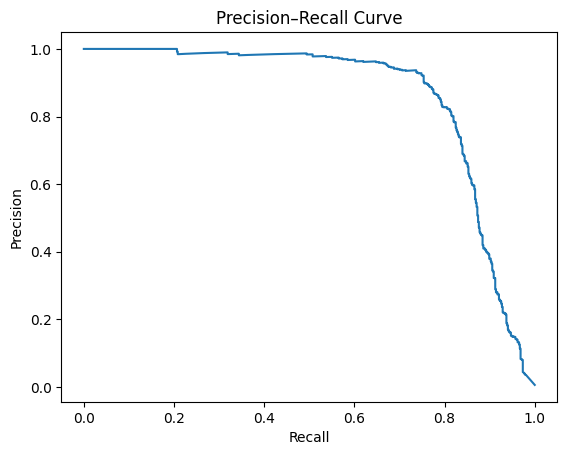

In [38]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_train, y_train_pred_proba_oof)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

In [39]:
# Find threshold that achieves recall >= 0.90
# We iterate over all thresholds from the PR curve
target_recall = 0.90

# precision_recall_curve returns thresholds of length n-1
# so we align arrays
valid = recall[:-1] >= target_recall
if valid.any():
    # Among all thresholds with recall >= 0.90, pick the one with best precision
    best_idx = np.argmax(precision[:-1][valid])
    optimal_threshold = thresholds[valid][best_idx]
    print(f"Optimal threshold: {optimal_threshold:.4f}")
    print(f"Expected precision: {precision[:-1][valid][best_idx]:.4f}")
    print(f"Expected recall: {recall[:-1][valid][best_idx]:.4f}")
else:
    print("No threshold achieves recall >= 0.90. Lower the target.")

Optimal threshold: 0.0933
Expected precision: 0.3797
Expected recall: 0.9025


In [40]:
#Test results with optimal thereshold
y_test_pred_optimal_thereshold=(y_pred_prob >= optimal_threshold).astype(int)

In [41]:
results_df = pd.DataFrame({"actual": y_test,
                           "predicted": y_test_pred_optimal_thereshold}) #Store results in a dataframe

confusion_matrix_final = pd.crosstab(index= results_df['actual'],
                               columns = results_df['predicted'])
confusion_matrix_final

predicted,0,1
actual,,
0,25713,70
1,24,127


In [42]:
##Scores with optimal thereshold
#Score
# Accuracy
acc_optimal_thereshold = accuracy_score(y_test, y_test_pred_optimal_thereshold)
print("Accuracy:", acc_optimal_thereshold)

# Precision (binary)
prec_optimal_thereshold = precision_score(y_test, y_test_pred_optimal_thereshold)
print("Precision:", prec_optimal_thereshold)

# Recall
rec_optimal_thereshold = recall_score(y_test, y_test_pred_optimal_thereshold)
print("Recall:", rec_optimal_thereshold)

Accuracy: 0.9963754145137658
Precision: 0.6446700507614214
Recall: 0.8410596026490066


## END